In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get TIMIT pandas for metadata

In [2]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [3]:
df_paths

[PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_00.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_01.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_02.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_03.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_04.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_05.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_06.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_07.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_08.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_09.pdpkl')]

In [4]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [5]:
# pd.concat(meta_df, axis=0)

In [6]:
meta_df.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker', 'mixture_signal',
       'distractor_signal', '_original_distractor_timit_indices',
       'distractor_words', 'distractor_speakers', 'distractor_conditions',
       'distractor_sex', 'snrs', 'cue_snr', 'stim_subset'],
      dtype='object')

### Get experimental results csv

In [7]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [8]:
results_files


[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/Batch_367265_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/Batch_367493_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/Batch_367574_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/full_length_pilot_set_0000/Batch_367588_batch_results.csv')]

In [9]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)

# set_ix, word, snr, cond, speaker_sex, orig_df_ix = file_name_to_labels(file_name)
# print(file_name)
# print(f"{word} at {snr} dB snr with {cond} target sex ({speaker_sex}), ds = {set_ix} original ix = {orig_df_ix}")




In [10]:
df.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker', 'mixture_signal',
       'distractor_signal', '_original_distractor_timit_indices',
       'distractor_words', 'distractor_speakers', 'distractor_conditions',
       'distractor_sex', 'snrs', 'cue_snr', 'stim_subset'],
      dtype='object')

In [11]:
results_dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(columns={0:"stim_file_name"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth['participant'] = ix
    
    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    results = responses.join(truth)
    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_file_name'].map(file_name_to_labels))
    orig_dataset_ix = results['stim_subset'][0]
    meta_subset = meta_df[meta_df.stim_subset == orig_dataset_ix]
    results['distractor_words'] = meta_subset.loc[results.orig_df_ix, ['distractor_words']].values
    results['distractor_sex'] = meta_subset.loc[results.orig_df_ix, ['distractor_sex']].values

    results_dfs.append(results)

In [12]:
results = pd.concat(results_dfs, axis=0)

#### Process results csv to plotting format

In [13]:
results

,guessed_word,stim_file_name,participant,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex
trial 0,formed,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,majority,-6,1,f,2,[appointed],m
trial 1,other,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,other,0,4,m,294,"[through, place, change, means]",ffff
trial 10,related,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,related,-6,ssn,ssn,186,ssn,ssn
trial 100,inside,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,inside,3,2,m,362,"[change, change]",ff
trial 101,status,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,status,3,ssn,ssn,54,ssn,ssn
...,...,...,...,...,...,...,...,...,...,...,...
trial 95,strategy,https://mcdermottlab.mit.edu/mturk_stimuli/img...,3,4,strategy,clean,catch_trial,m,401,catch trial,NaN
trial 96,value,https://mcdermottlab.mit.edu/mturk_stimuli/img...,3,4,their,-3,1,f,19,[their],f
trial 97,times,https://mcdermottlab.mit.edu/mturk_stimuli/img...,3,4,times,-3,2,m,321,"[names, continued]",ff
trial 98,expected,https://mcdermottlab.mit.edu/mturk_stimuli/img...,3,4,expected,3,4,m,225,"[larger, occurred, social, there]",mmmf


In [14]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [15]:
results.head()

,guessed_word,stim_file_name,participant,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex,accuracy
trial 0,formed,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,majority,-6,1,f,2,[appointed],m,0
trial 1,other,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,other,0,4,m,294,"[through, place, change, means]",ffff,1
trial 10,related,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,related,-6,ssn,ssn,186,ssn,ssn,1
trial 100,inside,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,inside,3,2,m,362,"[change, change]",ff,1
trial 101,status,https://mcdermottlab.mit.edu/mturk_stimuli/img...,0,0,status,3,ssn,ssn,54,ssn,ssn,1


In [16]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [17]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [18]:
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > .85].index

In [19]:
good_results = results[results.participant.isin(good_participants)]

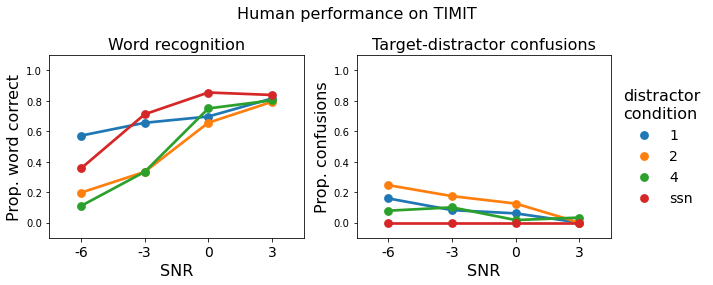

In [20]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=good_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=good_results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Human performance on TIMIT', size=fontsize)
plt.tight_layout()


## Get model results all subsets

In [21]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_stim_01_rms_MultiDistractorAttnCNN/version_0/')
timit_results = list(parent_path.rglob("*.csv"))

In [22]:
model_results = pd.read_csv(timit_results[0])

In [23]:
model_results.shape

(4120, 3)

In [24]:
model_results.head()

,ACC/test_fg_acc,pred_word_ix,step
0,0.0,18.0,0
1,1.0,712.0,1
2,1.0,547.0,2
3,1.0,409.0,3
4,0.0,286.0,4


In [25]:
model_results = model_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in model_results.index})
model_results['pred_word_ix'] = model_results['pred_word_ix'].astype('int') 

In [26]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_all_attn_stim_for_model_eval_0_1rms.pdpkl')

In [27]:
model_meta_df.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker', 'mixture_signal',
       'distractor_signal', '_original_distractor_timit_indices',
       'distractor_words', 'distractor_speakers', 'distractor_conditions',
       'distractor_sex', 'snrs', 'cue_snr', 'dataset', 'distractor_word_ints'],
      dtype='object')

In [28]:
model_results['guessed_word'] = model_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
model_results['true_word'] = model_meta_df.loc[model_results.orig_df_ix, ['word']].values
model_results['distractor_words'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_words']].values
model_results['distractor_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_sex']].values
model_results['snr'] = model_meta_df.loc[model_results.orig_df_ix, ['snrs']].values.astype('str')
model_results['distractor_condition'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
model_results['target_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['speaker_sex']].values


In [29]:
model_results['confusions'] = model_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [30]:
# snr_order = ['-6', '-3', '0', '3' ]
# hue_order = ['1', '2', '4', 'ssn']
# # y_labels = np.linspace(0.1,1,6).round(2)
# fontsize = 16

# fig, axs = plt.subplots(1,2, figsize=(10,4))
# axs = axs.ravel()

# g = sns.pointplot( data=model_results, x = 'snr', y = 'accuracy', order=snr_order,
#             hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
#             ax=axs[0])

# g1 = sns.pointplot( data=model_results, x = 'snr', y = 'confusions', order=snr_order,
#             hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
#             ax=axs[1])

# axs[0].set_title("Word recognition", fontsize=fontsize)
# axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


# axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
# axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

# axs[0].set_xlabel("SNR", fontsize=fontsize)
# axs[1].set_xlabel("SNR", fontsize=fontsize)


# g.set_xticklabels(snr_order, size=14)
# g1.set_xticklabels(snr_order, size=14)



# axs[0].set_ylim((-0.1,1.1))
# axs[1].set_ylim((-0.1,1.1))

# axs[0].get_legend().remove()
# sns.move_legend(g1, title='distractor\ncondition', 
#                 loc="center right", bbox_to_anchor=(1.4, .5),
#                 frameon=False, title_size=fontsize, fontsize=fontsize-2)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
# plt.tight_layout()


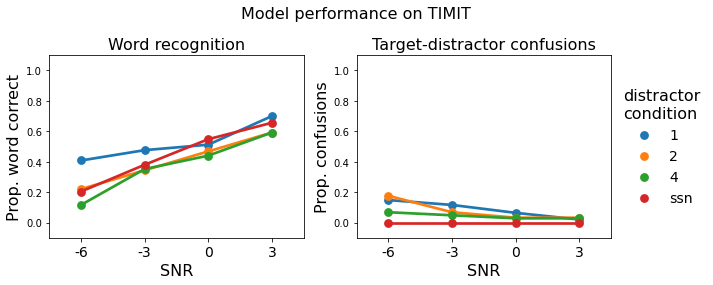

In [31]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=model_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=model_results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()


## Put on same plots 

First look at N talkers by SNR for model and human (separate pannels for model and humans)

Then look at single talker accuracy and sinlge talker confusions ( lines for model and human ) 

In [32]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_115916/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [33]:
all_results = pd.concat([good_results, model_results])

### Error by N Talker 

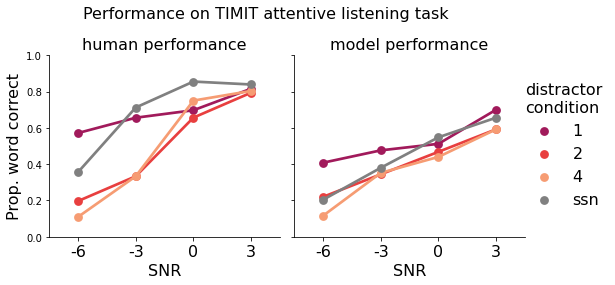

In [202]:
fontsize = 16

snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'


g = sns.catplot(kind='point',
    data=all_results,
    x='snr', y='accuracy',
    order = snr_order,
    hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
    col='subject',
    ci=None, seed=1, height=4, aspect=0.75
)

 
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
g.fig.tight_layout()
# g.fig.savefig('../demo_plots/timit_human_v_model.png')

In [36]:
# fontsize = 16

# snr_order = ['-6', '-3', '0', '3' ]
# hue_order = ['1', '2', '4', 'ssn']

# distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
# distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
# distractor_palette['ssn'] = 'grey'


# g = sns.catplot(kind='point',
#     data=all_results,
#     x='snr', y='accuracy',
#     order = snr_order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
#     ci=None, seed=1, height=4, aspect=0.75
# )

 
# g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)
# # g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
# g.legend.set_title("")
# # plt.yscale('log')
# sns.move_legend(g, title='distractor\ncondition', 
#                 loc="center right", bbox_to_anchor=(1.15, .5),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# # plt.tick_params(axis='both', which='major', labelsize=16)

# plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
# g.fig.tight_layout()
# # g.fig.savefig('../demo_plots/timit_human_v_model.png')

In [37]:
distractor_palette

{'1': (0.63139686, 0.10067417, 0.35664819),
 '2': (0.90848638, 0.24568473, 0.24598324),
 '4': (0.96298491, 0.6126247, 0.45145074),
 'ssn': 'grey'}

In [38]:
# snr_order = ['-6', '-3', '0', '3' ]
# hue_order = ['1', '4', 'ssn']
# # y_labels = np.linspace(0.1,1,6).round(2)
# fontsize = 16

# fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)
# axs = axs.ravel()


# g = sns.pointplot( data=all_results[all_results.subject=='human'], x = 'snr', y = 'accuracy', order=snr_order,
#             hue ='distractor_condition', height=4,
#             hue_order=hue_order, palette=distractor_palette,
#             ax=axs[0])

# g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
#             hue ='distractor_condition', height=4, linestyles='--',
#             hue_order=hue_order, palette=distractor_palette,
#             ax=axs[1])

# axs[0].set_title("Human performance", fontsize=fontsize)
# axs[1].set_title("Model performance", fontsize=fontsize)


# axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
# axs[1].set_ylabel("", fontsize=fontsize)

# axs[0].set_xlabel("SNR", fontsize=fontsize)
# axs[1].set_xlabel("SNR", fontsize=fontsize)


# g.set_xticklabels(snr_order, size=14)
# g1.set_xticklabels(snr_order, size=14)

# sns.despine()


# # axs[0].set_ylim((-0.02,1))
# # axs[1].set_ylim((-0.02,1))


# axs[0].get_legend().remove()

# sns.move_legend(g1, title='distractor\ncondition', 
#                 loc="center right", bbox_to_anchor=(1.5, .5),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.ylim(0,1)
# fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
# plt.tight_layout()
# # plt.savefig('../demo_plots/timit_human_v_model.svg')

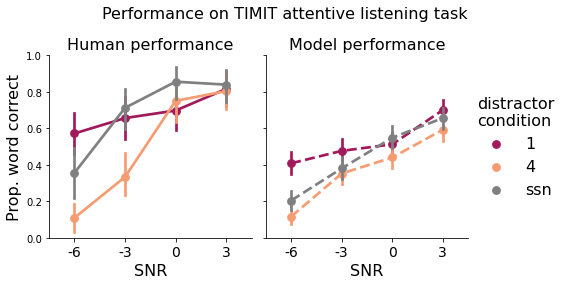

In [203]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'



fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)
axs = axs.ravel()


g = sns.pointplot( data=all_results[all_results.subject=='human'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', height=4,
            hue_order=hue_order, palette=distractor_palette,
            ax=axs[0])

g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', height=4, linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            ax=axs[1])

axs[0].set_title("Human performance", fontsize=fontsize)
axs[1].set_title("Model performance", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


# axs[0].set_ylim((-0.02,1))
# axs[1].set_ylim((-0.02,1))


axs[0].get_legend().remove()

sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.5, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
plt.ylim(0,1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
plt.tight_layout()
# plt.savefig('../demo_plots/timit_human_v_model.svg')

In [254]:

sumstats = (all_results[all_results.subject=='human'].groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

full_stats = (sumstats.groupby(['distractor_condition', 'snr'])['mean'].agg(['mean', 'sem']).reset_index())

In [277]:
full_stats

,distractor_condition,snr,mean,sem
1,1,-6,0.504615,0.176899
9,4,-6,0.093333,0.048074
14,ssn,-6,0.327407,0.078098
13,ssn,-3,0.725926,0.063289
0,1,-3,0.584242,0.156185
8,4,-3,0.286667,0.099555
2,1,0,0.665833,0.119306
10,4,0,0.700000,0.110151
15,ssn,0,0.822222,0.085143
16,ssn,3,0.823333,0.038442


In [256]:
full_stats[~full_stats['snr'].isin(['clean', 2])]

,distractor_condition,snr,mean,sem
0,1,-3,0.584242,0.156185
1,1,-6,0.504615,0.176899
2,1,0,0.665833,0.119306
3,1,3,0.777778,0.135173
4,2,-3,0.315088,0.105546
5,2,-6,0.176970,0.055241
6,2,0,0.633333,0.104775
7,2,3,0.740513,0.146935
8,4,-3,0.286667,0.099555
9,4,-6,0.093333,0.048074


In [257]:
[v for k,v in distractor_palette.items() if k !='2']

[(0.63139686, 0.10067417, 0.35664819),
 (0.96298491, 0.6126247, 0.45145074),
 'grey']

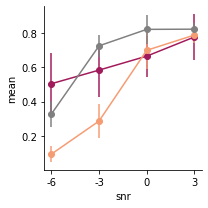

In [260]:
snrs = ['-6', '-3', '0', '3']
mapping = {snr: i for i, snr in enumerate(snrs)}
key = full_stats['snr'].map(mapping)    
full_stats = full_stats.iloc[key.argsort()]
full_stats = full_stats[~full_stats['distractor_condition'].isin(['catch_trial', '2'])]

def errplot(x, y, yerr, ax, **kwargs):
    data = kwargs.pop("data")
    data.plot(x=x, y=y, yerr=yerr, ax=ax, marker='o', color=distractor_palette[kwargs['label']])

g = sns.FacetGrid(full_stats, hue="distractor_condition")
g.map_dataframe(errplot, "snr", "mean", "sem", plt.gca())

In [285]:
full_stats

,distractor_condition,snr,mean,sem
1,1,-6,0.504615,0.176899
9,4,-6,0.093333,0.048074
14,ssn,-6,0.327407,0.078098
13,ssn,-3,0.725926,0.063289
0,1,-3,0.584242,0.156185
8,4,-3,0.286667,0.099555
2,1,0,0.665833,0.119306
10,4,0,0.700000,0.110151
15,ssn,0,0.822222,0.085143
16,ssn,3,0.823333,0.038442


/tmp/ipykernel_115916/705393894.py:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  error_colors = np.array([[distractor_palette[hue]] * len(snr_order) for hue in hue_order]).flatten()


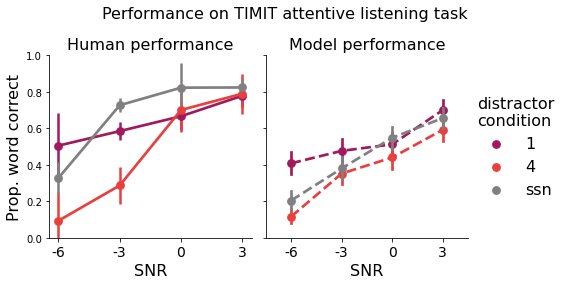

In [343]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)
axs = axs.ravel()
distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'


error_colors = np.array([[distractor_palette[hue]] * len(snr_order) for hue in hue_order]).flatten()

g = sns.pointplot( data=full_stats, x = 'snr', y = 'mean', order=snr_order,
            hue ='distractor_condition', height=4, ci=None,
            hue_order=hue_order, palette=distractor_palette,
            ax=axs[0])

x_coords = []
y_coords = []
for point_pair in g.collections:
    for x, y in point_pair.get_offsets():
        x_coords.append(x)
        y_coords.append(y)
        
g.errorbar(x_coords,y_coords, yerr=full_stats['sem'].values,
            ecolor=error_colors, fmt='', zorder=-1, c='None',
            elinewidth=2.5)

g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', height=4, linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            ax=axs[1])


axs[0].set_title("Human performance", fontsize=fontsize)
axs[1].set_title("Model performance", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


# axs[0].set_ylim((-0.02,1))
# axs[1].set_ylim((-0.02,1))


axs[0].get_legend().remove()

sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.5, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
plt.ylim(0,1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
plt.tight_layout()
# plt.savefig('../demo_plots/timit_human_v_model.svg')

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,


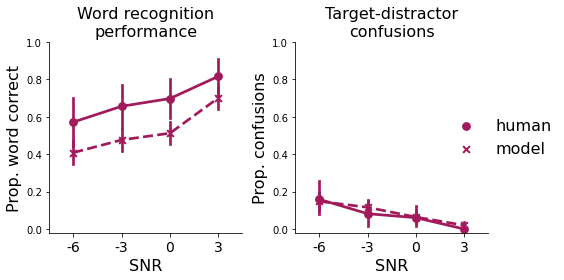

In [44]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.ravel()

to_plot = all_results[all_results.distractor_condition == '1']

g = sns.pointplot( data=to_plot, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[0])

g1 = sns.pointplot( data=to_plot, x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[1])

axs[0].set_title("Word recognition\nperformance", fontsize=fontsize)
axs[1].set_title("Target-distractor\nconfusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


axs[0].set_ylim((-0.02,1))
axs[1].set_ylim((-0.02,1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, fontsize=fontsize)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()
plt.savefig('../demo_plots/timit_single_word_rec_v_confusions.svg')

### Scratch code for looking at talker sex similarity 

[0, 1, 2, 0, 1, 0, 1, 2, 3, 4]

In [350]:
## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['f', 'm', 'ff', 'mf', 'mm', 'ffff', 'mfff', 'mmff', 'mmmf', 'mmmm']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['mmff'] = distractor_palette['mf']

[['f', 'm'], ['ff', 'mf', 'mm'], ['ffff', 'mfff', 'mmff', 'mmmf', 'mmmm']]


In [357]:
# snrs = ['-6', '-3', '0', '3']
# mapping = {snr: i for i, snr in enumerate(snrs)}


# sumstats = (all_results[all_results.subject=='human'].groupby(["snr", 'participant',
#                                                                "distractor_condition",
#                                                               "target_sex",
#                                                                "distractor_sex"])
#                      .accuracy
#                      .agg(["mean"])
#                      .reset_index())

# full_stats = (sumstats.groupby(["snr",
#                                "distractor_condition",
#                               "target_sex",
#                                "distractor_sex"])['mean'].agg(['mean', 'sem']).reset_index())


# key = full_stats['snr'].map(mapping)    
# full_stats = full_stats.iloc[key.argsort()]
# full_stats = full_stats[~full_stats['distractor_condition'].isin(['catch_trial', 'ssn'])]

# def errplot(x, y, yerr, **kwargs):
#     data = kwargs.pop("data")
#     print(data)
#     data.plot(x=x, y=y, yerr=yerr, ax=plt.gca(), marker='o', color=distractor_palette[kwargs['label']])

# g = sns.FacetGrid(full_stats, row='target_sex', col='distractor_condition', hue="distractor_sex")
# g.map_dataframe(errplot, "snr", "mean", "sem")

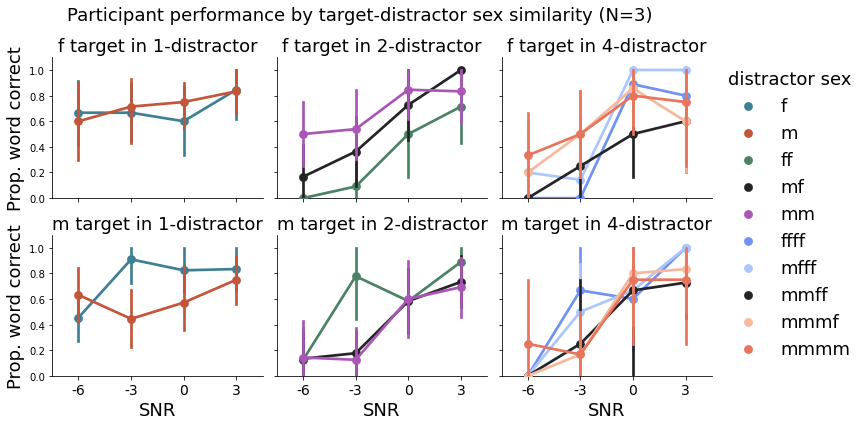

In [271]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-6', '-3', '0', '3']

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18


to_plot = all_results[all_results.subject=='human']


g = sns.catplot( kind='point',
    data=to_plot[to_plot['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='accuracy',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
     seed=1,
     height=3,
    palette=distractor_palette,
    order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Participant performance by target-distractor sex similarity (N=3)', size=fontsize)
plt.tight_layout()


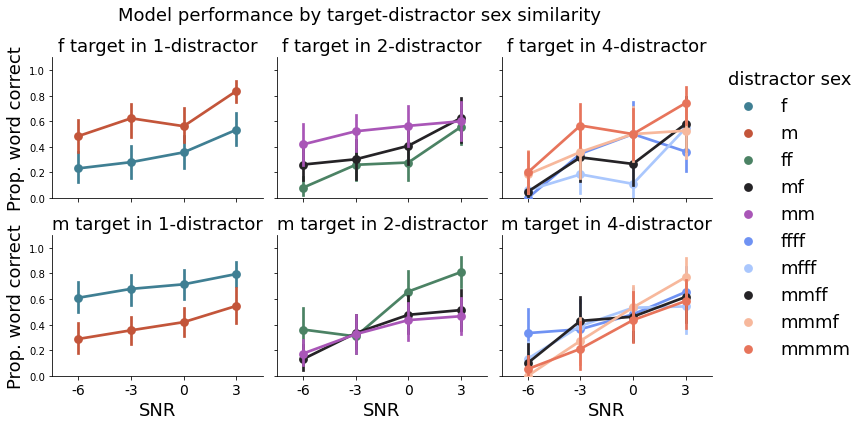

In [276]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-6', '-3', '0', '3']

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18

to_plot = all_results[all_results.subject=='model']

g = sns.catplot( kind='point',
    data=to_plot[to_plot['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='accuracy',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
    seed=1,
    height=3,
    palette=distractor_palette,
   order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance by target-distractor sex similarity', size=fontsize)
plt.tight_layout()


### Plot Human confusions by target-distractor sex

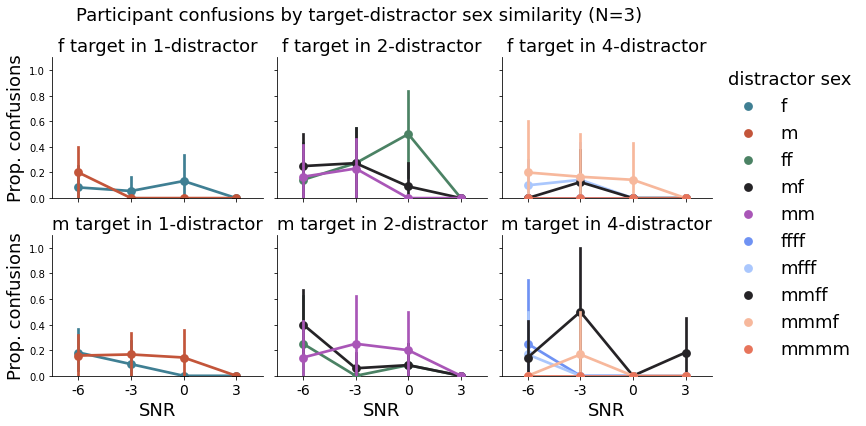

In [269]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-6', '-3', '0', '3']

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18


to_plot = all_results[all_results.subject=='human']


g = sns.catplot( kind='point',
    data=to_plot[to_plot['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='confusions',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
    seed=1, error='sem',
     height=3,
    palette=distractor_palette,
    order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. confusions", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(-0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Participant confusions by target-distractor sex similarity (N=3)', size=fontsize)
plt.tight_layout()


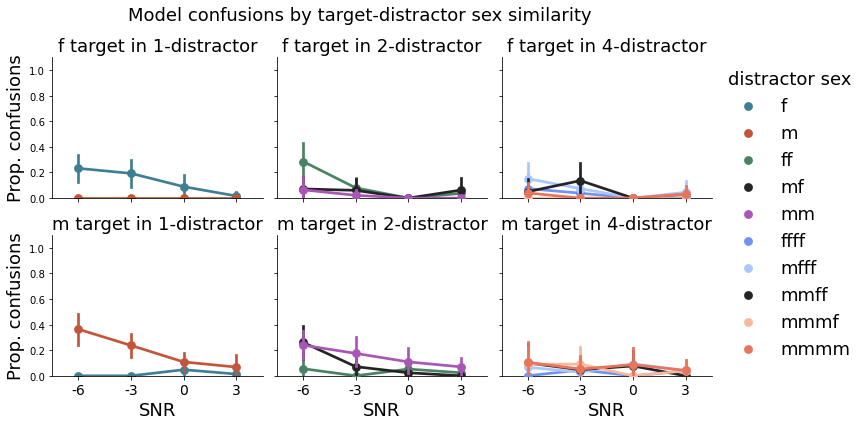

In [270]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-6', '-3', '0', '3']

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18


to_plot = all_results[all_results.subject=='model']


g = sns.catplot( kind='point',
    data=to_plot[to_plot['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='confusions',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
    seed=1,
    height=3,
    palette=distractor_palette,
    order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. confusions", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model confusions by target-distractor sex similarity', size=fontsize)
plt.tight_layout()
